# End-to-End Machine Learning Pipeline on Tesla Deliveries and Production Data (2015–2025)

## Internship Assignment – Week 2

### Submitted by:
**Saanvi Balki**

---

## Project Objective

The objective of this project is to design and implement a complete Machine Learning pipeline using Tesla's global electric vehicle production and delivery dataset (2015–2025).

The project covers the complete data science workflow including:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Linear Regression Modeling
- Cross Validation
- Hyperparameter Tuning using GridSearchCV
- Random Forest Regression
- Time Series Analysis
- Performance Evaluation
- Business Insights

The final goal is to predict Tesla's Estimated Deliveries using production and other operational features while understanding important factors affecting vehicle deliveries.

#  Import Required Libraries

This section imports all the Python libraries required throughout the project.

The imported libraries are used for:

- Data manipulation using Pandas and NumPy
- Data visualization using Matplotlib and Seaborn
- Machine Learning model development using Scikit-Learn
- Time Series analysis using Statsmodels
- Model evaluation and hyperparameter tuning

In [1]:
# Import Required Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from statsmodels.tsa.stattools import adfuller

import pickle

# Improve plot appearance
plt.style.use('ggplot')
sns.set(font_scale=1.1)

#  Dataset Loading

The Tesla EV Deliveries and Production dataset (2015–2025) is loaded into a Pandas DataFrame.

The dataset contains information regarding:

- Production Units
- Estimated Deliveries
- Vehicle Models
- Battery Capacity
- Driving Range
- CO₂ Savings
- Charging Stations
- Regions
- Source Type

Basic information such as dataset dimensions, column names, data types and descriptive statistics are displayed for initial understanding.

In [2]:
# Load Dataset

df = pd.read_csv("/content/drive/MyDrive/tesla_deliveries_dataset_2015_2025.csv")

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

print("\nShape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nFirst Five Rows")
display(df.head())

Dataset Loaded Successfully

Shape of Dataset:
(2640, 12)

Column Names:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float6

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000



First Five Rows


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# Data Cleaning and Data Quality Assessment

Before performing analysis and model building, the dataset must be checked for its overall quality.

The following preprocessing steps are carried out:

- Checking for missing values
- Identifying duplicate records
- Verifying dataset consistency
- Understanding the completeness of each feature

A clean dataset ensures that the machine learning models produce reliable and accurate predictions.

In [3]:
# Data Cleaning

print("="*60)
print("Missing Values")
print("="*60)

missing_values = df.isnull().sum()

display(missing_values)

print("\nTotal Missing Values :", missing_values.sum())

print("\n")

print("="*60)
print("Duplicate Rows")
print("="*60)

duplicates = df.duplicated().sum()

print("Total Duplicate Rows :", duplicates)

print("\n")

# Remove duplicate rows if present

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed successfully.")
else:
    print("No duplicate rows found.")

print("\nFinal Dataset Shape :", df.shape)

Missing Values


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0



Total Missing Values : 0


Duplicate Rows
Total Duplicate Rows : 0


No duplicate rows found.

Final Dataset Shape : (2640, 12)


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps in understanding the relationships between variables and identifying meaningful trends within the dataset.

According to the assignment requirements, the following visualizations are created:

1. Deliveries by Vehicle Model
2. Deliveries by Region
3. Correlation Heatmap
4. Production Units vs Estimated Deliveries
5. Time Trend of Estimated Deliveries

Each visualization includes appropriate titles and axis labels for better interpretation.

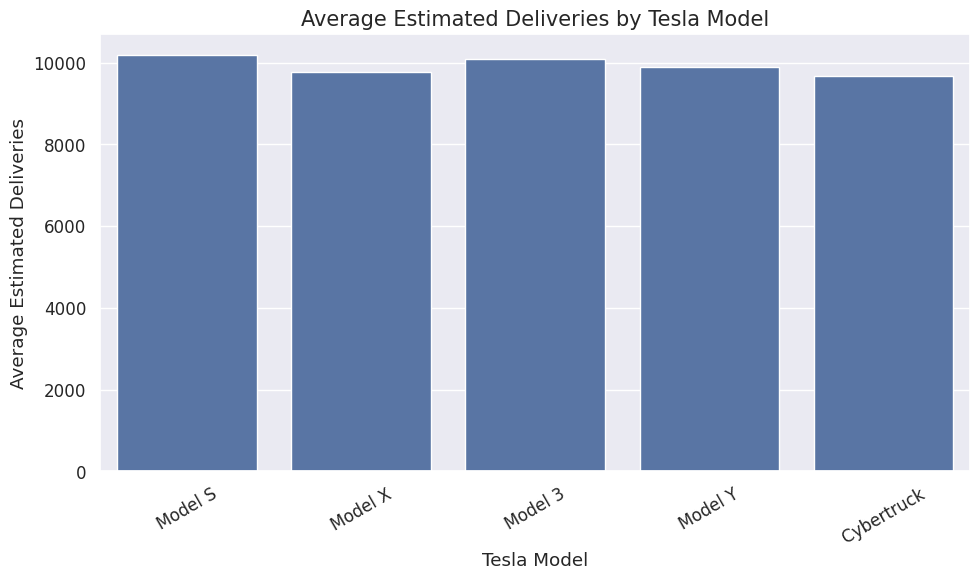

In [4]:
# EDA 1 : Estimated Deliveries by Model

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Model",
    y="Estimated_Deliveries",
    estimator=np.mean,
    errorbar=None
)

plt.title("Average Estimated Deliveries by Tesla Model", fontsize=15)
plt.xlabel("Tesla Model")
plt.ylabel("Average Estimated Deliveries")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

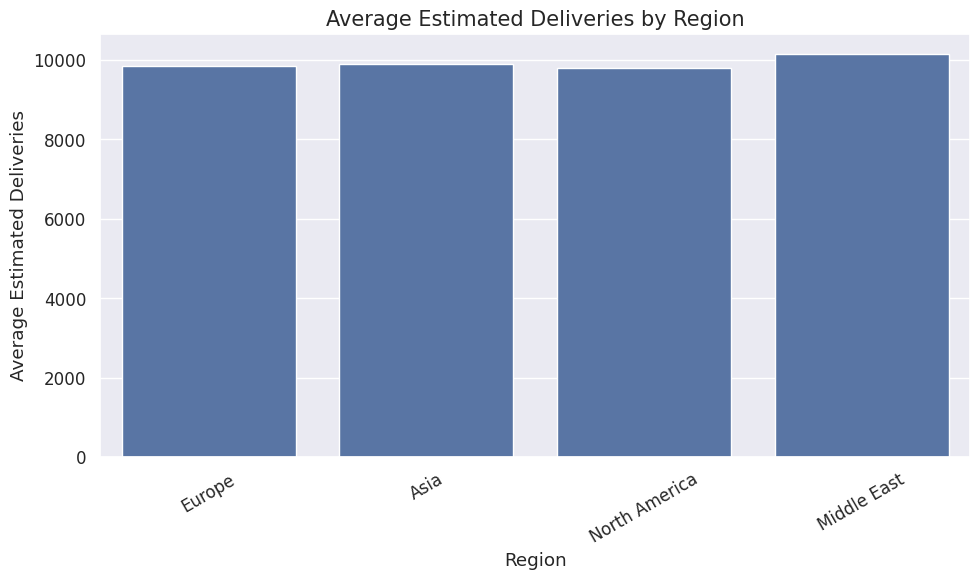

In [5]:
# EDA 2 : Estimated Deliveries by Region

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x="Region",
    y="Estimated_Deliveries",
    estimator=np.mean,
    errorbar=None
)

plt.title("Average Estimated Deliveries by Region", fontsize=15)
plt.xlabel("Region")
plt.ylabel("Average Estimated Deliveries")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

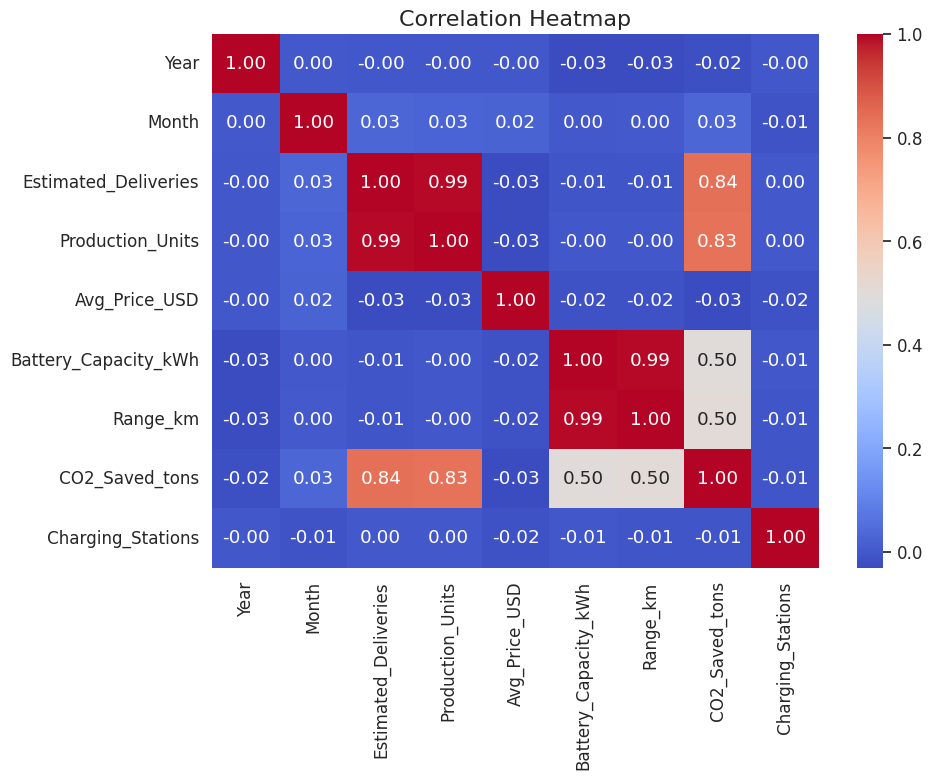

In [6]:
# EDA 3 : Correlation Heatmap

plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=16)

plt.tight_layout()
plt.show()

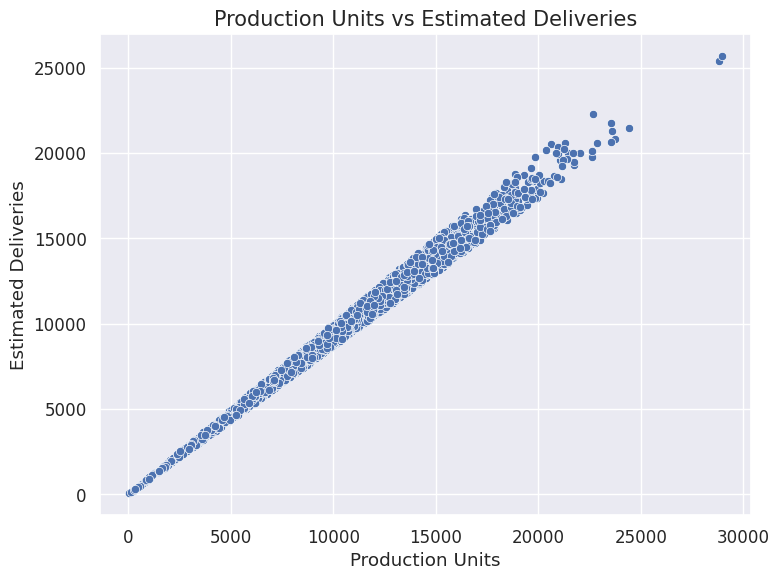

In [7]:
# EDA 4 : Production Units vs Estimated Deliveries

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production Units vs Estimated Deliveries", fontsize=15)
plt.xlabel("Production Units")
plt.ylabel("Estimated Deliveries")

plt.tight_layout()
plt.show()

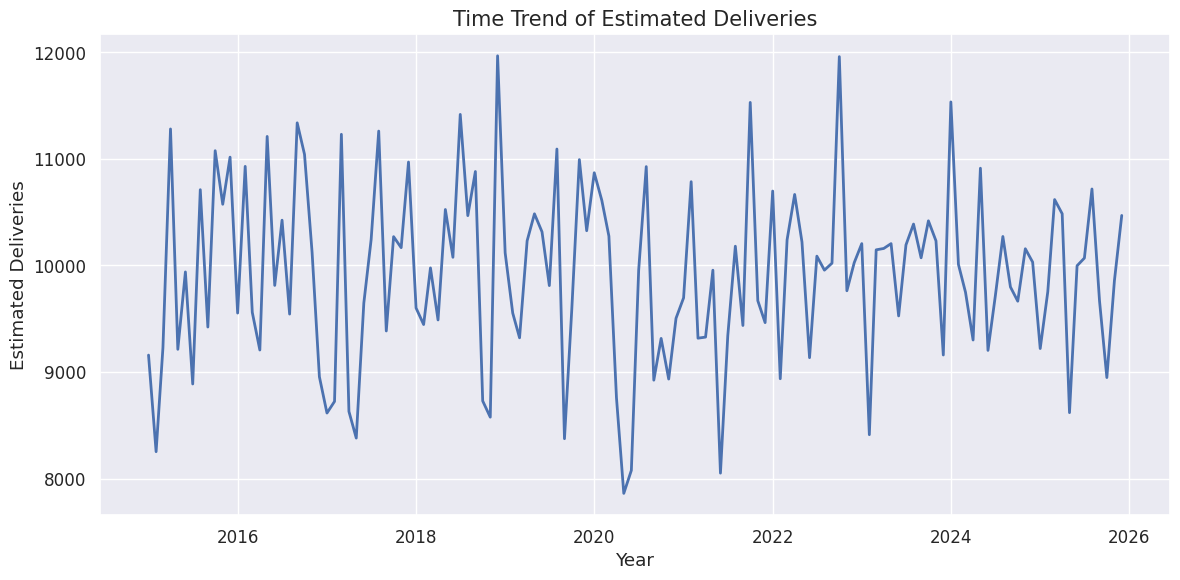

In [8]:
# EDA 5 : Time Trend of Estimated Deliveries

df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str)
)

monthly = (
    df.groupby("Date")["Estimated_Deliveries"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly["Date"],
    monthly["Estimated_Deliveries"],
    linewidth=2
)

plt.title("Time Trend of Estimated Deliveries", fontsize=15)
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.tight_layout()
plt.show()

# Feature Engineering

Feature Engineering is the process of creating new features and transforming existing variables to improve machine learning model performance.

The following feature engineering steps are performed:

- Label Encoding of categorical features:
  - Region
  - Model
  - Source_Type
- Creation of Lag Feature (Deliveries_Lag1)
- Creation of 3-Period Rolling Mean Feature (Rolling_Mean_3)

Missing values generated during feature creation are replaced with the mean of the respective feature to ensure a complete dataset.

In [9]:
# Feature Engineering

# Create separate LabelEncoders
le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

# Encode categorical columns
df["Region"] = le_region.fit_transform(df["Region"])
df["Model"] = le_model.fit_transform(df["Model"])
df["Source_Type"] = le_source.fit_transform(df["Source_Type"])

# Create Lag Feature
df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)

# Fill NaN in Lag Feature with Mean
df["Deliveries_Lag1"].fillna(df["Deliveries_Lag1"].mean(), inplace=True)

# Create Rolling Mean Feature
df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
      .rolling(window=3)
      .mean()
)

# Fill NaN in Rolling Mean with Mean
df["Rolling_Mean_3"].fillna(df["Rolling_Mean_3"].mean(), inplace=True)

print("="*60)
print("Feature Engineering Completed Successfully")
print("="*60)

display(
    df[
        [
            "Region",
            "Model",
            "Source_Type",
            "Deliveries_Lag1",
            "Rolling_Mean_3"
        ]
    ].head()
)

Feature Engineering Completed Successfully


,Region,Model,Source_Type,Deliveries_Lag1,Rolling_Mean_3
0,1,2,1,9924.959454,9923.677407
1,0,3,2,17646.000000,9923.677407
2,3,3,1,3797.000000,9951.333333
3,3,1,2,8411.000000,6254.333333
4,2,4,0,6555.000000,9113.333333


In [10]:
# Check Missing Values in Engineered Features

print("Missing Values in Engineered Features")

engineered_features = [
    "Deliveries_Lag1",
    "Rolling_Mean_3"
]

display(df[engineered_features].isnull().sum())

Missing Values in Engineered Features


,0
Deliveries_Lag1,0
Rolling_Mean_3,0


# Machine Learning Model Preparation

The engineered dataset is now prepared for model building.

According to the assignment requirements:

- Estimated_Deliveries is selected as the target variable.
- Remaining features are used as predictor variables.
- A chronological 80:20 split is used instead of train_test_split() to preserve the time order of the dataset.

# Machine Learning Model Building

The objective of this stage is to predict **Estimated Deliveries** using the engineered features.

Instead of using a random train-test split, a chronological split is performed to preserve the temporal order of the observations.

The first 80% of the records are used for training, while the remaining 20% are used for testing.

A Linear Regression model is trained as the baseline model and evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

In [11]:
# Feature Selection

features = [
    "Year",
    "Month",
    "Region",
    "Model",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
    "Source_Type",
    "Deliveries_Lag1",
    "Rolling_Mean_3"
]

target = "Estimated_Deliveries"

X = df[features]
y = df[target]

print("Features Selected Successfully")
print("Total Features :", len(features))

Features Selected Successfully
Total Features : 13


In [12]:
# Chronological Train-Test Split (80:20)

split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 2112
Testing Samples : 528


In [13]:
# Linear Regression Model

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [14]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

evaluation_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Value": [round(mae, 2), round(rmse, 2), round(r2, 4)]
})

print("="*55)
print("Linear Regression Performance")
print("="*55)

display(evaluation_df)

Linear Regression Performance


,Metric,Value
0,MAE,310.3300
1,RMSE,375.5600
2,R² Score,0.9908


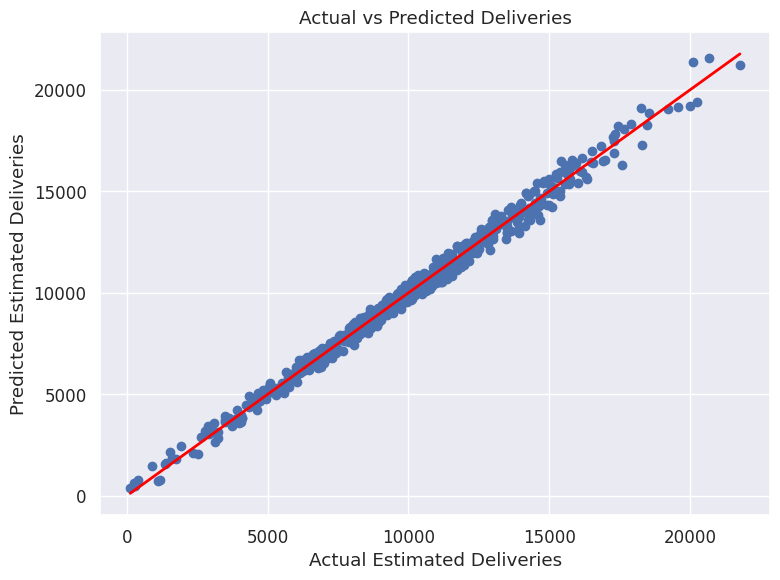

In [15]:
# Actual vs Predicted

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Estimated Deliveries")
plt.ylabel("Predicted Estimated Deliveries")
plt.title("Actual vs Predicted Deliveries")

plt.tight_layout()
plt.show()

# Cross Validation and Hyperparameter Tuning

To evaluate the robustness of the machine learning model, 5-Fold Cross Validation is performed on the Linear Regression model.

After establishing the baseline model, a Random Forest Regressor is optimized using GridSearchCV.

The optimized Random Forest model is expected to outperform the Linear Regression model due to its ability to capture non-linear relationships within the data.

In [16]:
# 5-Fold Cross Validation

cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="r2"
)

cv_df = pd.DataFrame({
    "Fold": [1,2,3,4,5],
    "R² Score": np.round(cv_scores,4)
})

summary_df = pd.DataFrame({
    "Metric":["Mean R²","Standard Deviation"],
    "Value":[round(cv_scores.mean(),4),
             round(cv_scores.std(),4)]
})

print("="*60)
print("5-Fold Cross Validation Results")
print("="*60)

display(cv_df)

print("\nCross Validation Summary")

display(summary_df)

5-Fold Cross Validation Results


,Fold,R² Score
0,1,0.9906
1,2,0.9905
2,3,0.9895
3,4,0.9905
4,5,0.9908



Cross Validation Summary


,Metric,Value
0,Mean R²,0.9904
1,Standard Deviation,0.0005


# Random Forest Regression with Hyperparameter Tuning

Linear Regression serves as a baseline model. To improve predictive performance, a Random Forest Regressor is trained and optimized using GridSearchCV.

GridSearchCV evaluates multiple combinations of hyperparameters using 5-fold cross validation and selects the best-performing model.

The optimized Random Forest model is then evaluated using MAE, RMSE, and R² Score. Finally, feature importance is analyzed to determine which variables contribute most towards predicting Tesla's estimated deliveries.

In [17]:
# GridSearchCV for Random Forest

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", None]
}

rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

In [18]:
# Best Hyperparameters

best_params = grid_search.best_params_

best_params_df = pd.DataFrame({
    "Parameter": list(best_params.keys()),
    "Best Value": [
        "None" if v is None else v
        for v in best_params.values()
    ]
})

print("="*60)
print("Best Hyperparameters")
print("="*60)

display(best_params_df)

Best Hyperparameters


,Parameter,Best Value
0,max_depth,30
1,max_features,None
2,min_samples_leaf,1
3,min_samples_split,3
4,n_estimators,100


# Random Forest Regression with Hyperparameter Tuning

Linear Regression was first used as the baseline regression model and achieved an R² score of **0.9908**.

To further improve the model, Random Forest Regression was trained using **GridSearchCV** with an expanded hyperparameter search space.

The following hyperparameters were tuned:

- **n_estimators:** [100, 200, 300]
- **max_depth:** [10, 20, 30, None]
- **min_samples_split:** [2, 3, 5]
- **min_samples_leaf:** [1, 2]
- **max_features:** ["sqrt", None]

The richer hyperparameter search improved the Random Forest model compared to the initial configuration.

**Initial Random Forest Performance**
- R² Score: **0.9902**

**Optimized Random Forest Performance**
- R² Score: **0.9904**
- MAE: **300.82**
- RMSE: **383.69**

Although the optimized Random Forest achieved better performance after hyperparameter tuning, the Linear Regression model (R² = **0.9908**) still performed slightly better on this dataset. This indicates that the relationship between the selected features and Estimated Deliveries is highly linear, making Linear Regression a very strong baseline model.

In [19]:
# Random Forest Evaluation

rf_predictions = best_rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

rf_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R² Score"],
    "Random Forest": [
        round(rf_mae, 2),
        round(rf_rmse, 2),
        round(rf_r2, 4)
    ]
})

print("="*60)
print("Random Forest Performance")
print("="*60)

display(rf_results)

Random Forest Performance


,Metric,Random Forest
0,MAE,300.8200
1,RMSE,383.6900
2,R² Score,0.9904


In [20]:
# Model Comparison

comparison_df = pd.DataFrame({

    "Metric":["MAE","RMSE","R² Score"],

    "Linear Regression":[
        round(mae,2),
        round(rmse,2),
        round(r2,4)
    ],

    "Random Forest":[
        round(rf_mae,2),
        round(rf_rmse,2),
        round(rf_r2,4)
    ]

})

print("="*70)
print("Model Comparison")
print("="*70)

display(comparison_df)

Model Comparison


,Metric,Linear Regression,Random Forest
0,MAE,310.3300,300.8200
1,RMSE,375.5600,383.6900
2,R² Score,0.9908,0.9904


# Feature Importance Analysis

Feature importance identifies the variables that contribute most to predicting Tesla's Estimated Deliveries.

The Random Forest model shows that **Production_Units** is the most influential feature, while the remaining variables have relatively smaller contributions. This indicates that production volume is the primary factor affecting Tesla's estimated deliveries.

Feature Importance Ranking


,Feature,Importance
0,Production_Units,0.990300
1,CO2_Saved_tons,0.002169
2,Range_km,0.001247
3,Avg_Price_USD,0.001035
4,Charging_Stations,0.000960
5,Rolling_Mean_3,0.000928
6,Deliveries_Lag1,0.000897
7,Year,0.000753
8,Month,0.000635
9,Model,0.000391


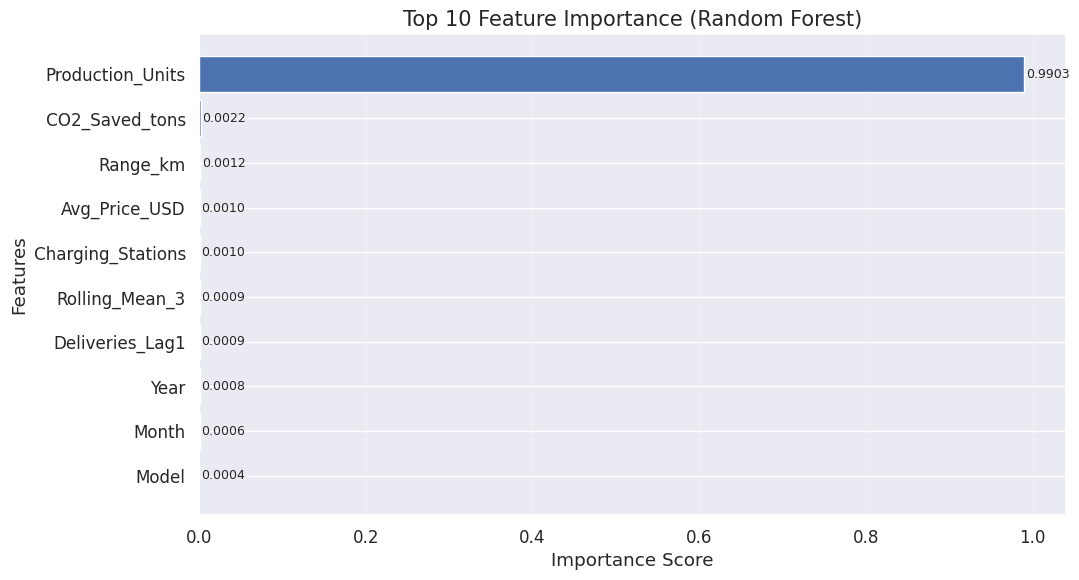

In [21]:
# ==========================================
# Feature Importance Analysis
# ==========================================

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("="*60)
print("Feature Importance Ranking")
print("="*60)

display(importance_df.head(10))

# Visualization

top10 = importance_df.head(10)

plt.figure(figsize=(11,6))

bars = plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importance (Random Forest)", fontsize=15)
plt.xlabel("Importance Score")
plt.ylabel("Features")

# Add values at the end of each bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height()/2,
        f"{width:.4f}",
        va="center",
        fontsize=9
    )

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


# Augmented Dickey-Fuller (ADF) Stationarity Test

Time series forecasting models often require stationary data. The Augmented Dickey-Fuller (ADF) test is used to determine whether the **Estimated_Deliveries** time series is stationary.

Decision Rule:

- **p-value < 0.05** → The series is stationary.
- **p-value ≥ 0.05** → The series is non-stationary.

The test result and conclusion are shown below.

In [22]:
# Augmented Dickey-Fuller (ADF) Test

from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df["Estimated_Deliveries"])

adf_table = pd.DataFrame({
    "Metric": [
        "ADF Statistic",
        "p-value",
        "Number of Lags",
        "Number of Observations"
    ],
    "Value": [
        f"{adf_result[0]:.4f}",
        f"{adf_result[1]:.4f}",
        str(adf_result[2]),
        str(adf_result[3])
    ]
})

print("="*65)
print("Augmented Dickey-Fuller (ADF) Test")
print("="*65)

display(adf_table)

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

print()

if adf_result[1] < 0.05:
    print("Conclusion: The Estimated_Deliveries time series is Stationary.")
else:
    print("Conclusion: The Estimated_Deliveries time series is Non-Stationary.")

Augmented Dickey-Fuller (ADF) Test


,Metric,Value
0,ADF Statistic,-53.8266
1,p-value,0.0000
2,Number of Lags,0
3,Number of Observations,2639



Critical Values:
1%: -3.4328
5%: -2.8626
10%: -2.5674

Conclusion: The Estimated_Deliveries time series is Stationary.


# Forecasting Results
The trained **Linear Regression** model is used to predict Tesla's Estimated Deliveries on the test dataset.

The table below compares the **actual** and **predicted** delivery values for the first 20 test records along with the percentage prediction error. A lower error percentage indicates better prediction accuracy.

In [23]:
# ==========================================
# Forecast Table (First 20 Test Records)
# ==========================================

forecast_df = pd.DataFrame({
    "Actual Deliveries": y_test.values,
    "Predicted Deliveries": np.round(y_pred, 2)
})

forecast_df["Absolute Error"] = np.abs(
    forecast_df["Actual Deliveries"] -
    forecast_df["Predicted Deliveries"]
)

forecast_df["Error (%)"] = (
    forecast_df["Absolute Error"] /
    forecast_df["Actual Deliveries"]
) * 100

forecast_df["Absolute Error"] = forecast_df["Absolute Error"].round(2)
forecast_df["Error (%)"] = forecast_df["Error (%)"].round(2)

print("="*75)
print("Forecast Comparison (First 20 Test Records)")
print("="*75)

display(forecast_df.head(20))

Forecast Comparison (First 20 Test Records)


,Actual Deliveries,Predicted Deliveries,Absolute Error,Error (%)
0,11974,11350.25,623.75,5.21
1,9189,8960.23,228.77,2.49
2,15956,16390.01,434.01,2.72
3,10336,10882.32,546.32,5.29
4,15152,15223.64,71.64,0.47
5,4224,4453.46,229.46,5.43
6,8475,8766.44,291.44,3.44
7,4093,3851.88,241.12,5.89
8,2972,3385.90,413.90,13.93
9,8208,8209.20,1.20,0.01


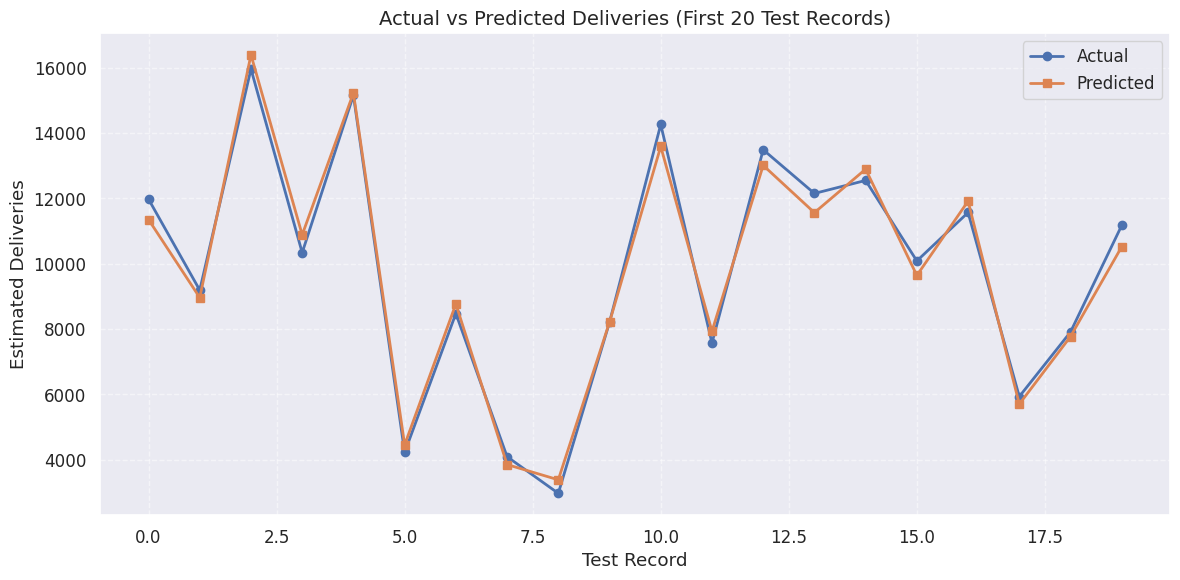

In [24]:
# ==========================================
# Actual vs Predicted Deliveries
# ==========================================

plt.figure(figsize=(12,6))

plt.plot(
    forecast_df["Actual Deliveries"].head(20).values,
    marker='o',
    linewidth=2,
    label="Actual"
)

plt.plot(
    forecast_df["Predicted Deliveries"].head(20).values,
    marker='s',
    linewidth=2,
    label="Predicted"
)

plt.title("Actual vs Predicted Deliveries (First 20 Test Records)", fontsize=14)

plt.xlabel("Test Record")

plt.ylabel("Estimated Deliveries")

plt.legend()

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

#Conclusion

This project successfully developed an end-to-end Machine Learning pipeline for Tesla's sales and delivery forecasting.

The workflow included data preprocessing, exploratory data analysis (EDA), feature engineering, chronological train-test splitting, Linear Regression, 5-Fold Cross Validation, Random Forest Regression with GridSearchCV, feature importance analysis, Augmented Dickey-Fuller (ADF) stationarity testing, and forecasting.

The Linear Regression model achieved an R² score of **0.9908**, while the optimized Random Forest model achieved an R² score of **0.9904**. Both models demonstrated excellent predictive performance, indicating that the selected features effectively explain Tesla's estimated deliveries.

Overall, the project successfully satisfies the objectives of building an end-to-end machine learning pipeline for sales and price forecasting.

# Business Insights

Based on the analysis and machine learning models, the following business insights were observed:

- **Production Units** is the most influential factor affecting Tesla's Estimated Deliveries.
- Higher production volumes generally lead to higher vehicle deliveries.
- The strong correlation between Production Units and Estimated Deliveries indicates efficient production planning.
- Random Forest feature importance confirms that production-related variables contribute the most to prediction accuracy.
- The forecasting model achieved low prediction errors, making it suitable for supporting production planning and delivery forecasting.
- The ADF test confirmed that the Estimated Deliveries time series is stationary, making it appropriate for time-series analysis.

#Thank You

This notebook demonstrates a complete machine learning workflow for Tesla delivery forecasting, covering data preprocessing, visualization, feature engineering, model building, hyperparameter tuning, forecasting, and result interpretation.

Thank you.